# Institutional Holdings from SEC 13F Bulk Data

**Chapter 4: Fundamental and Alternative Data**
**Docker image**: `ml4t`
**Section Reference**: Section 4.1 (The Point-in-Time Pipeline)

## Purpose

Notebook 02 read one manager's Form 13F through a library. This one reads all of them. The SEC
publishes every quarter's filings as a single archive: several million positions from around
seven thousand managers, which is the whole institutional cross-section of the US equity market
in one file, free.

Working at that scale changes what the exercise is about. A single filing can be read and
sanity-checked by eye; seven thousand cannot, and among them are filers who transposed a
column, reported in the wrong unit, or spelled a company's name in a way no other filer used.
Most of this notebook is the screening that has to happen before an aggregate over the file
means anything: every one of those errors reaches a ranking intact, and none of them announces
itself.

## Learning Objectives

After completing this notebook, you will be able to:

- Load a quarter of the SEC's bulk 13F archive and identify the columns that make a position
  row unique.
- Select one filing per manager per quarter when the archive holds originals, amendments and
  two report periods at once.
- Detect filings whose reported values are in the wrong unit, using a quantity the filing
  itself makes checkable, and account for what screening them out removes.
- Aggregate positions across managers on an identifier rather than on a name.
- Measure how widely a stock is held and read that as a crowding proxy with its limits stated.
- Build the two edge sets a holdings graph needs, and say which artifact a downstream notebook
  should actually read.

## Prerequisites

One quarter of the bulk archive, about 80 MB:

```bash
python data/equities/positioning/13f_download.py --mode bulk --quarters 2024Q3
```

## Cross-References

- **Upstream**: `data/equities/positioning/13f_download.py --mode bulk` (SEC quarterly data sets)
- **Related**: [`02_sec_filing_explorer`](02_sec_filing_explorer.ipynb) (one manager's 13F through a library)
- **Downstream**: `22_rag_financial_research/07_institutional_holdings_graph.py`, which reads
  the canonical edge artifact through `load_13f_edges` rather than rebuilding it

**Data source**: https://www.sec.gov/data-research/sec-markets-data/form-13f-data-sets

In [1]:
"""Institutional Holdings from SEC 13F Bulk Data - analyze top managers and ownership networks."""

import plotly.express as px
import polars as pl

from data import load_13f_bulk_holdings
from utils.style import COLORS, show_plotly_with_alt

The two screening bounds below are the settings that decide which filings are believed. They
bracket the price of a share of anything a 13F can report: a stock trading under a dollar is
not in a 13F portfolio at a material size, and nothing trades above ten thousand dollars a
share except a handful of names that do not move a total. A filing whose positions imply a
price outside that bracket has reported its values in a different unit from everyone else.

In [2]:
QUARTER = "2024Q3"  # SEC filing-window label; a Q3 window spans 1 September to 30 November
TOP_N = 500  # managers carried into the holdings analysis, ranked by reported value
MIN_IMPLIED_PRICE = 1.0  # a filing implying less than this per share is screened out
MAX_IMPLIED_PRICE = 10_000.0  # and so is one implying more
MIN_SHARED_MANAGERS = 5  # managers two stocks must share before they get a co-ownership edge
CO_OWNERSHIP_UNIVERSE = 500  # stocks entering the pairwise co-ownership pass
THRESHOLD_GRID = [5, 50, 100, 150, 200, 250, 300, 350]  # thresholds the edge density is measured at

## 1. The archive

The downloader parses the SEC's quarterly zip once and writes one parquet per quarter. Each row
is one position in one filing.

| Column | Meaning |
| --- | --- |
| `cik` | The manager's Central Index Key, which identifies the filer permanently |
| `accession_no` | The filing's own identifier; a manager may have several in one window |
| `cusip` | The security's identifier, and the only reliable key for a holding |
| `issuer` | The company name **as that filer typed it** |
| `value_thousands` | The reported dollar value of the position |
| `shares` | The reported number of shares |
| `filing_date` | The date the filing reached EDGAR |
| `company_name` | The manager's name as it appears on the cover page |

In [3]:
holdings = load_13f_bulk_holdings(QUARTER)

print(f"Positions: {len(holdings):,}")
print(f"Filings: {holdings['accession_no'].n_unique():,}")
print(f"Managers by CIK: {holdings['cik'].n_unique():,}")
print(f"Securities by CUSIP: {holdings['cusip'].n_unique():,}")
print(f"Filing window: {holdings['filing_date'].min()} to {holdings['filing_date'].max()}")

Positions: 2,863,210
Filings: 7,764
Managers by CIK: 7,355
Securities by CUSIP: 34,446
Filing window: 2024-09-03 to 2024-11-29


### A name is not a key

`issuer` is free text that each filer types, so the same security arrives under many spellings.
Anything that groups on it will split one company into several, and the effect is worst on the
most widely held names, which is exactly where an ownership analysis looks.

In [4]:
spellings = (
    holdings.group_by("cusip")
    .agg(pl.col("issuer").n_unique().alias("distinct_spellings"))
    .sort("distinct_spellings", descending=True)
)
print(f"Securities with more than one spelling: {(spellings['distinct_spellings'] > 1).sum():,}")
print(f"Most spellings of a single security: {spellings['distinct_spellings'].max()}")
holdings.filter(pl.col("cusip") == spellings["cusip"][0]).select("issuer").unique().head(6)

Securities with more than one spelling: 13,277
Most spellings of a single security: 179


issuer
str
"""Taiwan Semiconductors ADR"""
"""TAIWAN SEMICONDUCTOR MFG CO AD"""
"""TAIWAN SEMICONDUCTOR M FSPONSO…"
"""VANGUARD INTL EQUITY INDEX FDS…"
"""Taiwan Semiconductor-Spons ADR"""
"""TAIWAN SEMICONDUCTOR MANUFACTU…"


## 2. Screening the filings

### One filing per manager

A filing window catches originals, amendments, and occasionally two report periods, so a
manager can appear several times. The one to keep is the most recent, and *most recent* means
the latest filing date. An accession number looks sortable and is not: its first block is the
identifier of the filing agent that submitted the document, so ordering by it ranks agents
rather than dates.

In [5]:
filings = (
    holdings.group_by("accession_no", "cik", "company_name", "filing_date")
    .agg(
        pl.col("value_thousands").sum().alias("reported_value"),
        pl.col("cusip").n_unique().alias("positions"),
    )
    .sort(["cik", "filing_date", "accession_no"], descending=[False, True, True])
)
latest_filings = filings.group_by("cik", maintain_order=True).first()

print(f"Filings in the window: {len(filings):,}")
print(f"After keeping the latest per manager: {len(latest_filings):,}")
repeat_filers = filings.group_by("cik").len().filter(pl.col("len") > 1)
print(f"Managers with more than one filing: {len(repeat_filers):,}")
print(f"Filings those managers account for: {int(repeat_filers['len'].sum()):,}")

Filings in the window: 7,764
After keeping the latest per manager: 7,355
Managers with more than one filing: 82
Filings those managers account for: 491


### Filings whose numbers do not go together

The SEC changed the value field from thousands of dollars to whole dollars, and the column name
in this archive still carries the old convention. Filers did not all move at once, and share
counts are misreported too, so a filing can be wrong in either of its two numeric columns.

Which of them is wrong is not determinable from the file, and it does not need to be. The two
columns constrain each other: value divided by shares is a price per share, and a price has a
knowable range whatever units the two sides were meant to be in. A filing whose positions imply
a price outside that range is internally inconsistent, and that is enough to set it aside. The
median across a filing's positions is what makes the test robust to one bad row in an otherwise
sound filing.

In [6]:
implied_prices = (
    holdings.filter(pl.col("shares") > 0)
    .with_columns(implied_price=pl.col("value_thousands") / pl.col("shares"))
    .group_by("accession_no")
    .agg(pl.col("implied_price").median().alias("median_implied_price"))
)
screened = latest_filings.join(implied_prices, on="accession_no", how="left").with_columns(
    believable=pl.col("median_implied_price").is_between(MIN_IMPLIED_PRICE, MAX_IMPLIED_PRICE)
)

total_value = screened["reported_value"].sum()
kept = screened.filter(pl.col("believable"))
too_high = screened.filter(pl.col("median_implied_price") > MAX_IMPLIED_PRICE)
too_low = screened.filter(pl.col("median_implied_price") < MIN_IMPLIED_PRICE)
no_price = screened.filter(pl.col("median_implied_price").is_null())

print(f"Filings kept: {len(kept):,} of {len(screened):,}")
print(
    f"  implying more than ${MAX_IMPLIED_PRICE:,.0f} a share: {len(too_high):,}, carrying ${too_high['reported_value'].sum() / 1e12:.2f}T"
)
print(
    f"  implying less than ${MIN_IMPLIED_PRICE:,.0f} a share: {len(too_low):,}, carrying ${too_low['reported_value'].sum() / 1e12:.2f}T"
)
print(
    f"  reporting no shares at all: {len(no_price):,}, carrying ${no_price['reported_value'].sum() / 1e12:.2f}T"
)
print(f"Total reported value before screening: ${total_value / 1e12:.2f}T")
screened.filter(~pl.col("believable")).sort("reported_value", descending=True).head(5).select(
    "company_name",
    "positions",
    (pl.col("reported_value") / 1e9).round(1).alias("reported_bn"),
    pl.col("median_implied_price").round(2),
)

Filings kept: 6,681 of 7,355
  implying more than $10,000 a share: 4, carrying $3.09T
  implying less than $1 a share: 572, carrying $0.05T
  reporting no shares at all: 98, carrying $0.00T
Total reported value before screening: $56.19T


company_name,positions,reported_bn,median_implied_price
str,u32,f64,f64
"""Members Trust Co""",121,3084.0,138144.82
"""Linden Advisors LP""",277,11.9,0.93
"""TENOR CAPITAL MANAGEMENT Co., …",292,7.1,0.88
"""Saba Capital Management, L.P.""",354,4.8,0.92
"""WHITEBOX ADVISORS LLC""",317,3.7,0.85


The two failures are different sizes and different problems. A handful of filings imply prices
in the tens of thousands of dollars a share and carry trillions of reported value between them,
which is enough to put a small trust company above Vanguard in an unscreened ranking by size.
Several hundred more imply prices below a dollar; they are numerous and carry almost nothing, so
they distort a count of managers rather than a total. Reporting both, separately, is what lets a
reader decide whether the screen was the right one, and looking at a few of each is what
suggests where the error is - which the file itself never states.

In [7]:
top_managers = kept.sort("reported_value", descending=True).head(TOP_N)
print(
    f"Reported 13F equity value across the top {TOP_N} managers: ${top_managers['reported_value'].sum() / 1e12:.1f}T"
)
top_managers.head(15).select(
    "company_name",
    (pl.col("reported_value") / 1e9).round(1).alias("reported_bn"),
    "positions",
)

Reported 13F equity value across the top 500 managers: $48.0T


company_name,reported_bn,positions
str,f64,u32
"""VANGUARD GROUP INC""",5584.5,4351
"""BlackRock, Inc.""",4763.7,5176
"""STATE STREET CORP""",2457.6,4296
"""FMR LLC""",1643.4,5481
"""MORGAN STANLEY""",1379.4,7927
…,…,…
"""NORTHERN TRUST CORP""",610.9,4411
"""SUSQUEHANNA INTERNATIONAL GROU…",572.5,6042
"""WELLINGTON MANAGEMENT GROUP LL…",571.0,1893


A 13F reports long positions in US-listed equities and the options on them. It is not assets
under management: a manager's bonds, cash, private holdings and non-US listings are all absent,
and a short book is absent too. "Reported 13F value" is the phrase to use for these figures,
and the distinction matters most for exactly the managers at the top of this table, whose
non-equity businesses are large.

## 3. What the top managers hold

Restricting the position rows to the filings that survived screening gives the panel every
aggregate below is computed on. Grouping is on CUSIP, with one spelling of the name carried
through for legibility.

In [8]:
top_holdings = holdings.join(top_managers.select("accession_no"), on="accession_no", how="semi")
print(f"Positions held by the top {TOP_N} managers: {len(top_holdings):,}")

by_security = (
    top_holdings.group_by("cusip")
    .agg(
        pl.col("issuer").mode().first().alias("issuer"),
        pl.col("cik").n_unique().alias("managers_holding"),
        pl.col("value_thousands").sum().alias("aggregate_value"),
        pl.col("shares").sum().alias("aggregate_shares"),
    )
    .sort("managers_holding", descending=True)
)
by_security.head(15).select(
    "issuer",
    "managers_holding",
    (pl.col("aggregate_value") / 1e9).round(1).alias("aggregate_bn"),
)

Positions held by the top 500 managers: 1,242,699


issuer,managers_holding,aggregate_bn
str,u32,f64
"""MICROSOFT CORP""",441,2035.9
"""ALPHABET INC""",421,660.8
"""AMAZON COM INC""",419,1077.2
"""APPLE INC""",405,1961.3
"""META PLATFORMS INC""",402,904.9
…,…,…
"""ELI LILLY & CO""",384,635.1
"""JPMORGAN CHASE & CO.""",377,383.7
"""ADOBE INC""",373,168.4


### Breadth and size are different questions

The number of managers holding a security says how widely it is owned; the aggregate value says
how much is in it, and the two are only loosely related. Among the most widely held names below,
securities sitting within a few managers of each other differ by several times in the value
behind them. Crowding, in the sense that matters when everyone reaches for the exit at once, is
the breadth measure; size is what decides how much has to go through the exit.

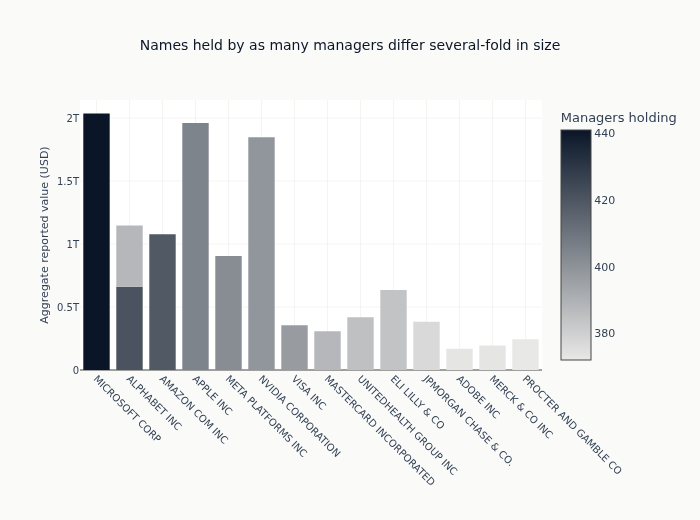

In [9]:
breadth_leaders = by_security.head(15).with_columns(
    pl.col("managers_holding").cast(pl.Int64)  # a uint reads as categorical and loses the scale
)
fig = px.bar(
    breadth_leaders.to_pandas(),
    x="issuer",
    y="aggregate_value",
    color="managers_holding",
    title="Names held by as many managers differ several-fold in size",
    labels={
        "aggregate_value": "Aggregate reported value (USD)",
        "issuer": "",
        "managers_holding": "Managers holding",
    },
    color_continuous_scale=[COLORS["silver_muted"], COLORS["blue"]],
)
fig.update_layout(xaxis_tickangle=45, margin=dict(b=150, r=120), height=520)
show_plotly_with_alt(
    fig,
    "Bar chart of the fifteen most widely held securities, ordered by the number of managers "
    "holding them and with bar height showing aggregate reported value. The bar heights vary "
    "several-fold across names that are held by similar numbers of managers.",
)

**What breadth does not measure.** A manager holding a hundred dollars of a stock counts the
same as one holding a billion, and an index fund holds nearly everything, so the top of a
breadth ranking is partly a list of index constituents. Weighting by position value, or
restricting to managers whose portfolios are concentrated, are the two usual corrections, and
both are choices a reader should make deliberately rather than inherit.

## 4. Ownership as a graph

Two edge sets come out of a holdings panel, and Chapter 23's graph models consume both. The
**manager to security** edges are bipartite, one per position, weighted by value. The
**security to security** edges connect two stocks whenever enough managers hold both, which is
what lets a signal on one name propagate to its co-owned peers.

In [10]:
manager_edges = top_holdings.group_by("cik", "company_name", "cusip").agg(
    pl.col("issuer").mode().first().alias("issuer"),
    pl.col("value_thousands").sum().alias("position_value"),
)
print(f"Manager-to-security edges: {len(manager_edges):,}")
manager_edges.head(5)

Manager-to-security edges: 633,166


cik,company_name,cusip,issuer,position_value
str,str,str,str,i64
"""0000932540""","""GROUP ONE TRADING LLC""","""773122106""","""ROCKET LAB USA INC""",17900184
"""0000884546""","""CHARLES SCHWAB INVESTMENT MANA…","""615111101""","""MONTROSE ENVIRONMENTAL GROUP""",6935257
"""0000354204""","""DIMENSIONAL FUND ADVISORS LP""","""578473100""","""MAYS J W INC""",396089
"""0001357955""","""ProShare Advisors LLC""","""565788106""","""MARA HOLDINGS INC""",944295
"""0000820027""","""AMERIPRISE FINANCIAL INC""","""256163106""","""DOCUSIGN INC""",59045176


In [11]:
def co_ownership_edges(positions: pl.DataFrame, min_shared: int, universe_cap: int) -> pl.DataFrame:
    """Securities held by at least `min_shared` managers in common, pairwise.

    The pass is quadratic in the number of securities, so it runs over the `universe_cap`
    most widely held rather than over the whole cross-section.
    """
    holders = (
        positions.group_by("cusip")
        .agg(
            pl.col("issuer").mode().first().alias("issuer"),
            pl.col("cik").unique().alias("managers"),
        )
        .with_columns(n_managers=pl.col("managers").list.len())
        .sort("n_managers", descending=True)
        .head(universe_cap)
    )
    cusips = holders["cusip"].to_list()
    issuers = holders["issuer"].to_list()
    manager_sets = [set(m) for m in holders["managers"].to_list()]

    edges = []
    for i in range(len(cusips)):
        for j in range(i + 1, len(cusips)):
            shared = len(manager_sets[i] & manager_sets[j])
            if shared >= min_shared:
                edges.append(
                    {
                        "cusip_a": cusips[i],
                        "issuer_a": issuers[i],
                        "cusip_b": cusips[j],
                        "issuer_b": issuers[j],
                        "shared_managers": shared,
                    }
                )
    return pl.DataFrame(
        edges,
        schema={
            "cusip_a": pl.Utf8,
            "issuer_a": pl.Utf8,
            "cusip_b": pl.Utf8,
            "issuer_b": pl.Utf8,
            "shared_managers": pl.Int64,
        },
    )

In [12]:
co_owned = co_ownership_edges(top_holdings, MIN_SHARED_MANAGERS, CO_OWNERSHIP_UNIVERSE)
# The universe is the cap or the number of securities available, whichever is smaller; using the
# cap where it exceeds what is there would divide by pairs that were never considered.
universe = min(CO_OWNERSHIP_UNIVERSE, top_holdings["cusip"].n_unique())
possible_pairs = universe * (universe - 1) // 2

print(f"Securities in the pairwise pass: {universe:,}")
print(f"Pairs considered: {possible_pairs:,}")
print(f"Edges at {MIN_SHARED_MANAGERS} or more shared managers: {len(co_owned):,}")
print(f"Density of the resulting graph: {len(co_owned) / possible_pairs:.1%}")

Securities in the pairwise pass: 500
Pairs considered: 124,750
Edges at 5 or more shared managers: 124,750
Density of the resulting graph: 100.0%


### The density is the first thing to look at

A graph in which every pair is connected carries no information, whatever the edges are called.
The threshold above was chosen as a round number rather than from the data, and the distribution
of shared-manager counts says what a round number was always going to miss.

In [13]:
shared_counts = co_ownership_edges(top_holdings, 0, universe)["shared_managers"]
print(
    f"Managers two of these securities share, at the tenth percentile: {shared_counts.quantile(0.1):.0f}"
)
print(f"Median: {shared_counts.median():.0f}")
print(f"Smallest overlap between any two: {shared_counts.min():,}")

density = pl.DataFrame(
    {
        "threshold": THRESHOLD_GRID,
        "density": [(shared_counts >= t).mean() for t in THRESHOLD_GRID],
    }
)
density

Managers two of these securities share, at the tenth percentile: 211
Median: 240
Smallest overlap between any two: 145


threshold,density
i64,f64
5,1.0
50,1.0
100,1.0
150,0.999944
200,0.962982
250,0.362156
300,0.042725
350,0.001186


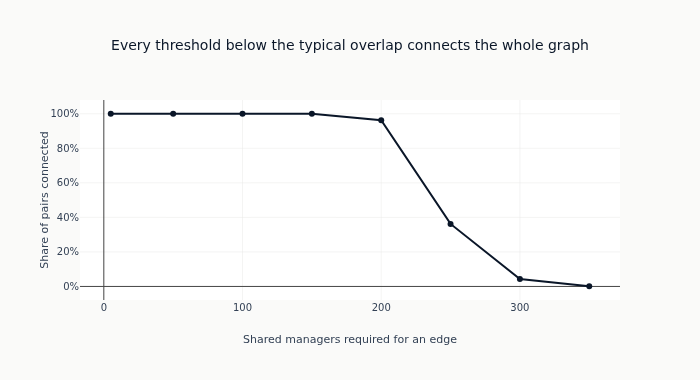

In [14]:
fig = px.line(
    density.to_pandas(),
    x="threshold",
    y="density",
    markers=True,
    title="Every threshold below the typical overlap connects the whole graph",
    labels={
        "threshold": "Shared managers required for an edge",
        "density": "Share of pairs connected",
    },
    color_discrete_sequence=[COLORS["blue"]],
)
fig.update_layout(height=380, yaxis_tickformat=".0%")
show_plotly_with_alt(
    fig,
    "Line chart of the share of security pairs that are connected against the number of shared "
    "managers required. The line sits at one hundred percent across most of the range and falls "
    "steeply only above two hundred shared managers.",
)

### Normalizing does not rescue it

The obvious repair is to divide the shared count by how widely the less-held of the two is
held, which is the overlap coefficient: one means every manager holding the rarer security also
holds the other. It corrects for breadth, and here it saturates too.

In [15]:
breadth = dict(zip(by_security["cusip"], by_security["managers_holding"], strict=True))
overlap = co_ownership_edges(top_holdings, 0, universe).with_columns(
    overlap_coefficient=pl.struct("cusip_a", "cusip_b", "shared_managers").map_elements(
        lambda row: row["shared_managers"] / min(breadth[row["cusip_a"]], breadth[row["cusip_b"]]),
        return_dtype=pl.Float64,
    )
)
print(f"Median overlap coefficient: {overlap['overlap_coefficient'].median():.2f}")
print(f"Share of pairs above 0.9: {(overlap['overlap_coefficient'] > 0.9).mean():.1%}")
overlap.sort("overlap_coefficient", descending=True).head(5).select(
    "issuer_a", "issuer_b", "shared_managers", pl.col("overlap_coefficient").round(3)
)

Median overlap coefficient: 0.90
Share of pairs above 0.9: 49.6%


issuer_a,issuer_b,shared_managers,overlap_coefficient
str,str,i64,f64
"""MICROSOFT CORP""","""INTUITIVE SURGICAL INC""",341,1.0
"""MICROSOFT CORP""","""SHERWIN WILLIAMS CO""",340,1.0
"""MICROSOFT CORP""","""MCDONALDS CORP""",340,1.0
"""MICROSOFT CORP""","""LINDE PLC""",338,1.0
"""MICROSOFT CORP""","""ZOETIS INC""",335,1.0


The pairs at the top of that list are not economically related to each other. They are ordinary
index constituents, and what the edge says is that the same large managers hold both, because
those managers hold the index.

The universe is the reason, and it was chosen two cells earlier: the five hundred most widely
held securities, held by the five hundred largest managers, are the securities and the managers
for which co-ownership is nearly universal by construction. A discriminating version of this
graph needs a universe that was not selected on breadth, or managers whose portfolios are
concentrated rather than index-tracking. Building the edges is easy; making them mean something
is a question about which slice of the file they are built from.

The edges here are illustrative. `22_rag_financial_research/07_institutional_holdings_graph.py`
reads the canonical artifact through `load_13f_edges`, which the downloader builds over the
curated multi-quarter panel rather than over one quarter of the bulk file.

## 5. Bulk archive against live filings

The two ingestion paths answer different questions, and the difference is timing.

| Mode | Source | Scope | Answers |
| --- | --- | --- | --- |
| `--mode bulk` | The quarterly zip | Every filer, one quarter | What did the whole institutional cross-section hold? |
| `--mode per-cik` | The submissions API and each filing's XML | A named list of managers, many quarters | How has this manager's book changed? |

A quarter's positions are reported as of the quarter end and are due forty-five days later, so
the newest position in a filing is at least six weeks old when it becomes public. The bulk
archive is assembled after the filing window closes, which adds several weeks more. Anything
that depends on reacting to a disclosure reads the individual filings from EDGAR as they land,
which is public information the moment it is submitted; the bulk file is for the cross-section,
not for the reaction.

## Key Takeaways

1. Group on the identifier, never on the name. A filer types the issuer name and thousands of
   securities in this archive carry more than one spelling, with the most widely held names
   carrying the most. A ranking built on names is wrong worst exactly where it is read.
2. A bulk regulatory file is not clean because it is official. A few filings are internally
   inconsistent and they land at the top of any ranking by size. The filing supplies its own
   check without needing to know which of its columns is wrong: value divided by shares is a
   price, and a price has a knowable range.
3. Say what a screen removed. Reporting the number of filings and the share of the total value
   dropped is what separates a screen from a quiet deletion.
4. An accession number is not a timestamp. Its leading block identifies the filing agent, so
   ordering by it ranks agents. Use the filing date.
5. Breadth and size are different measures of institutional interest and rank differently.
   Breadth is the crowding proxy, and it weights a hundred-dollar position the same as a
   billion-dollar one, which is the correction to make before acting on it.
6. Report a graph's density before believing its edges. Among widely held securities held by
   large managers, every pair shares hundreds of holders, so any round-number threshold connects
   everything and normalizing by breadth saturates as well. The edge set then describes index
   membership. Fixing it is a question about which slice of the file the graph is built from,
   not about the threshold.